# Reto: Propensión de conversión de clientes
**Objetivo:** ordenar a los clientes de diciembre 2026 según su probabilidad de convertir.
**Métrica:** Gini = 2·AUC − 1 (solo importa el *orden* de las predicciones).

Estructura del notebook:
1. Configuración y carga de datos
2. Análisis exploratorio (EDA)
3. Hallazgo clave: la variable `dias_ultima_interaccion` cambia en el tiempo (drift)
4. Ingeniería de variables
5. Validación temporal
6. Modelos: Regresión logística, LightGBM, CatBoost
7. Ensamble y selección
8. Interpretación (importancia de variables)
9. Entrenamiento final y archivo de entrega
10. Próximos pasos para el equipo

## 1. Configuración y carga de datos
En Colab: ejecuta la celda y sube los 4 CSV (`train.csv`, `test.csv`, `sample_submission.csv`, `metaData.csv`) cuando se abra el selector. Si ya están en la carpeta, no te los pedirá.

In [2]:
!pip install -q lightgbm catboost


In [3]:
!pip install scikit-learn

In [4]:
import os, time, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_predict, GroupKFold
from scipy.stats import rankdata
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
SEED = 42

DATA_DIR = os.environ.get('DATA_DIR', '.')
necesarios = ['train.csv', 'test.csv', 'sample_submission.csv']
if not all(os.path.exists(os.path.join(DATA_DIR, f)) for f in necesarios):
    try:
        from google.colab import files
        print('Train.csv, test.csv, sample_submission.csv y metaData.csv')
        files.upload()
        DATA_DIR = '.'
    except ImportError:
        raise FileNotFoundError('put CSV')

train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
sub   = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))
print('train', train.shape, '| test', test.shape, '| submission', sub.shape)
print('Valores faltantes en train:', train.isna().sum().sum(), '| en test:', test.isna().sum().sum())
train.head()

train (110100, 25) | test (9900, 24) | submission (9900, 2)
Valores faltantes en train: 0 | en test: 0


,id_cliente,mes,edad,ingresos,ratio_deuda_ingresos,antiguedad_cuenta_meses,numero_productos,saldo_promedio,dias_ultima_transaccion,ocupacion,region,canal_adquisicion,banda_riesgo,tiene_tarjeta_credito,activo_movil,es_nuevo_cliente,tiene_prestamo,antiguedad_direccion_meses,visitas_web_ultimos_90_dias,distancia_sucursal_km,dispositivo_principal,dia_preferido_pago,tiene_seguro,dias_ultima_interaccion,objetivo
0,1,202601,26,42120.349663,0.367310,139,2,40949.765573,67,professional,west,web,low,False,True,False,False,222,10,9.898223,android,21,True,67,0
1,2,202601,56,89837.390440,0.338092,29,2,35233.622561,304,manager,west,web,low,False,True,False,False,58,2,9.311922,ios,20,True,304,0
2,3,202601,34,45951.715455,0.444587,21,2,39486.902998,220,clerical,north,web,high,True,True,False,False,8,6,12.188249,android,12,False,220,0
3,4,202601,62,54673.148516,0.243261,43,2,300.000000,110,manual,north,partner,high,False,False,False,False,119,9,10.459796,ios,20,False,110,0
4,5,202601,37,100239.135609,0.230946,113,1,32066.808006,247,professional,north,partner,medium,True,True,False,False,25,6,36.502645,ios,13,False,247,1


## 2. Análisis exploratorio
### 2.1 Tasa de conversión por mes
Si la tasa es estable, el problema no tiene estacionalidad fuerte.

Tasa global de conversión: 0.1505


,filas,tasa
mes,,
202601,10400,0.146
202602,9800,0.157
202603,10300,0.148
202604,9600,0.153
202605,10100,0.157
202606,10350,0.155
202607,9700,0.145
202608,10050,0.144
202609,9900,0.141


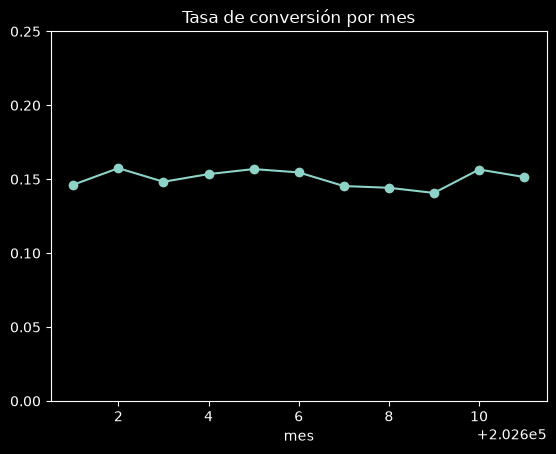

In [5]:
tasa_mes = train.groupby('mes')['objetivo'].agg(filas='size', tasa='mean')
print('Tasa global de conversión:', round(train.objetivo.mean(), 4))
display(tasa_mes.round(3))
tasa_mes['tasa'].plot(marker='o', title='Tasa de conversión por mes', ylim=(0, 0.25)); plt.show()

### 2.2 Estructura de panel: cada cliente aparece varios meses
Según el metaData, **un cliente que convierte ya no vuelve a aparecer**. Es decir, el panel es de *supervivencia*: cada mes vemos solo a los clientes que todavía no han convertido.

In [6]:
print('Clientes únicos en train:', train.id_cliente.nunique())
print('Clientes de test que ya estaban en train:', round(test.id_cliente.isin(train.id_cliente).mean(), 3))
print('Clientes con más de una conversión:', (train.groupby('id_cliente').objetivo.sum() > 1).sum())

# ¿Las variables cambian dentro de un mismo cliente?
num_cols = train.select_dtypes('number').columns.drop(['id_cliente', 'mes', 'objetivo'])
print('\nPromedio de valores distintos por cliente (1 = la variable no cambia):')
print(train.groupby('id_cliente')[list(num_cols)].nunique().mean().round(2))

Clientes únicos en train: 24628
Clientes de test que ya estaban en train: 0.814
Clientes con más de una conversión: 0

Promedio de valores distintos por cliente (1 = la variable no cambia):
edad                           1.00
ingresos                       1.00
ratio_deuda_ingresos           1.00
antiguedad_cuenta_meses        1.00
numero_productos               1.00
saldo_promedio                 1.00
dias_ultima_transaccion        1.00
antiguedad_direccion_meses     1.00
visitas_web_ultimos_90_dias    1.00
distancia_sucursal_km          1.00
dia_preferido_pago             1.00
dias_ultima_interaccion        2.82
dtype: float64


**Conclusión:** casi todas las variables son *fijas por cliente*. La única que cambia es `dias_ultima_interaccion` (ver sección 3). Calcular variaciones mes a mes de saldo o ingresos no aporta información.

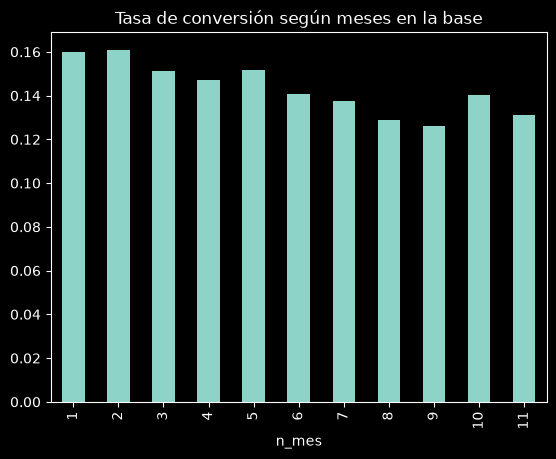

In [7]:
# Riesgo de conversión según cuántos meses lleva el cliente observado sin convertir
tmp = train.sort_values('mes').copy()
tmp['n_mes'] = tmp.groupby('id_cliente').cumcount() + 1
tmp.groupby('n_mes')['objetivo'].mean().plot(kind='bar', title='Tasa de conversión según meses en la base'); plt.show()

### 2.3 Poder predictivo de cada variable por separado
Gini univariado: cuánto ordena cada variable por sí sola (el signo indica la dirección).

In [8]:
gini = lambda y, p: 2 * roc_auc_score(y, p) - 1
g_uni = pd.Series({c: gini(train.objetivo, train[c]) for c in num_cols}).sort_values(key=abs, ascending=False)
display(g_uni.round(3).to_frame('gini_univariado'))

cats = ['ocupacion', 'region', 'canal_adquisicion', 'banda_riesgo', 'dispositivo_principal']
bools = ['tiene_tarjeta_credito', 'activo_movil', 'es_nuevo_cliente', 'tiene_prestamo', 'tiene_seguro']
for c in cats + bools:
    print(train.groupby(c)['objetivo'].agg(filas='size', tasa='mean').round(3), '\n')

,gini_univariado
numero_productos,0.114
dias_ultima_transaccion,-0.093
dias_ultima_interaccion,-0.058
antiguedad_cuenta_meses,0.017
ratio_deuda_ingresos,-0.017
saldo_promedio,0.013
edad,0.011
ingresos,0.009
visitas_web_ultimos_90_dias,-0.004
distancia_sucursal_km,0.003


               filas   tasa
ocupacion                  
clerical       33037  0.152
manager        11375  0.141
manual         30650  0.149
professional   24952  0.153
self_employed  10086  0.153 

         filas   tasa
region               
central  16655  0.146
east     19516  0.155
north    24088  0.150
south    22245  0.151
west     27596  0.150 

                   filas   tasa
canal_adquisicion              
branch             17103  0.141
call_center        16096  0.156
mobile             29068  0.151
partner            11430  0.145
web                36403  0.153 

              filas   tasa
banda_riesgo              
high          23142  0.087
low           51495  0.186
medium        35463  0.140 

                       filas   tasa
dispositivo_principal              
android                46241  0.151
ios                    35007  0.151
otro                    6442  0.145
web                    22410  0.150 

                       filas   tasa
tiene_tarjeta_credito        

## 3. Hallazgo clave: drift en `dias_ultima_interaccion`
En enero, `dias_ultima_interaccion` es **igual** a `dias_ultima_transaccion` en el 100% de las filas; esa proporción cae mes a mes y en el test de diciembre es casi 0%. Una variable cuyo comportamiento cambia con el tiempo es peligrosa: el modelo aprende un patrón que no existe en el mes que vamos a predecir.

,% filas con interaccion == transaccion
mes,
202601,1.000
202602,0.909
202603,0.819
202604,0.728
202605,0.637
202606,0.547
202607,0.457
202608,0.365
202609,0.276


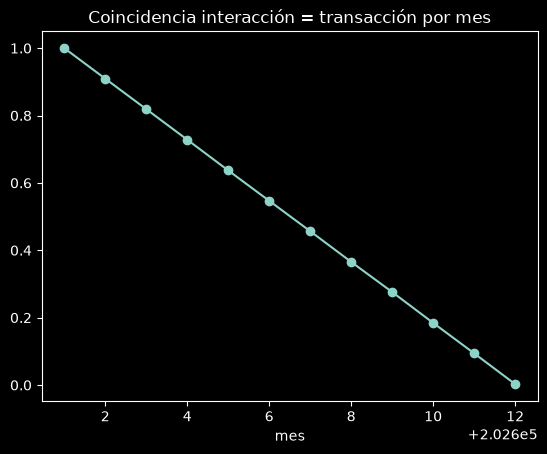

In [9]:
iguales = lambda d: (d.dias_ultima_interaccion == d.dias_ultima_transaccion)
comp = train.assign(igual=iguales(train)).groupby('mes')['igual'].mean()
comp.loc[202612] = iguales(test).mean()
display(comp.round(3).to_frame('% filas con interaccion == transaccion'))
comp.plot(marker='o', title='Coincidencia interacción = transacción por mes'); plt.show()

In [10]:
!pip install -U scikit-learn lightgbm

### Validación adversarial
Entrenamos un modelo que intente distinguir filas de **train** (enero a noviembre) de filas de **test** (diciembre). Si lo logra (AUC muy por encima de 0.5), las distribuciones difieren y el modelo final aprendería patrones que no se repiten en diciembre.

*Detalle importante:* usamos `GroupKFold` por `id_cliente`. Como el mismo cliente aparece en train y en test con variables casi idénticas, una partición aleatoria da resultados engañosos (AUC por debajo de 0.5).

In [11]:
import sklearn
import lightgbm as lgb

print(sklearn.__version__)
print(lgb.__version__)

1.9.1
4.7.0


In [12]:
adv = pd.concat([train.drop(columns='objetivo').assign(es_test=0), test.assign(es_test=1)], ignore_index=True)
for c in cats: adv[c] = adv[c].astype('category')
for c in bools: adv[c] = adv[c].astype(int)
adv['coincide_interaccion'] = iguales(adv).astype(int)   # derivada de la variable sospechosa
base_feats = [c for c in test.columns if c not in ['id_cliente', 'mes']]
escenarios = [('con dias_ultima_interaccion', base_feats + ['coincide_interaccion']),
              ('sin dias_ultima_interaccion', [f for f in base_feats if f != 'dias_ultima_interaccion'])]
for nombre, F in escenarios:
    p = cross_val_predict(lgb.LGBMClassifier(n_estimators=200, verbose=-1, random_state=SEED),
                          adv[F], adv.es_test, cv=GroupKFold(5), groups=adv.id_cliente,
                          method='predict_proba')[:, 1]
    print(f'AUC adversarial {nombre}: {roc_auc_score(adv.es_test, p):.3f}')

AUC adversarial con dias_ultima_interaccion: 0.771
AUC adversarial sin dias_ultima_interaccion: 0.519


**Decisión:** eliminamos `dias_ultima_interaccion`. Además casi no predice (la tasa de conversión es la misma tanto si coincide como si no).

## 4. Ingeniería de variables
Variables con sentido económico:
- `n_mes`: meses que el cliente lleva en la base sin convertir (efecto de supervivencia).
- `deuda`: ratio deuda/ingresos × ingresos = deuda absoluta.
- `saldo_ingresos`: colchón de liquidez relativo.
- `prod_por_anio`: intensidad de vinculación (productos por año de antigüedad).

In [13]:
df = pd.concat([train, test], ignore_index=True)
df['n_mes'] = df.sort_values('mes').groupby('id_cliente').cumcount() + 1
df['deuda'] = df.ratio_deuda_ingresos * df.ingresos
df['saldo_ingresos'] = df.saldo_promedio / df.ingresos
df['prod_por_anio'] = df.numero_productos / (df.antiguedad_cuenta_meses / 12 + 1)
for c in bools: df[c] = df[c].astype(int)

nums = ['edad', 'ingresos', 'ratio_deuda_ingresos', 'antiguedad_cuenta_meses', 'numero_productos',
        'saldo_promedio', 'dias_ultima_transaccion', 'antiguedad_direccion_meses',
        'visitas_web_ultimos_90_dias', 'distancia_sucursal_km', 'dia_preferido_pago']
nuevas = ['n_mes', 'deuda', 'saldo_ingresos', 'prod_por_anio']
F_BASE = nums + bools + cats            # sin dias_ultima_interaccion
F_FE   = F_BASE + nuevas
print(len(F_BASE), 'variables base |', len(F_FE), 'con ingeniería')

21 variables base | 25 con ingeniería


## 5. Validación temporal
**Regla de oro:** validar como se va a evaluar. El test es un mes *futuro*, así que entrenamos con los meses anteriores a M y validamos en M, para M = septiembre, octubre y noviembre. Una validación aleatoria pondría al mismo cliente (con variables idénticas) en entrenamiento y validación, y el Gini saldría inflado.

In [14]:
MESES_VALID = [202609, 202610, 202611]
trn = df[df.mes <= 202611]

def validar(fn_modelo, F):
    """Devuelve el Gini por mes de validación y las predicciones fuera de muestra."""
    res, preds = {}, {}
    for m in MESES_VALID:
        a, b = trn[trn.mes < m], trn[trn.mes == m]
        p = fn_modelo(a, b, F)
        res[m] = gini(b.objetivo, p); preds[m] = p
    return res, preds

## 6. Modelos
- **Regresión logística:** línea base interpretable (coeficientes).
- **LightGBM:** árboles con *gradient boosting*, capta no linealidades e interacciones.
- **CatBoost:** boosting que maneja categóricas de forma nativa.

In [15]:
def modelo_logistico(a, b, F):
    pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), [f for f in F if f in cats]),
                             ('num', StandardScaler(), [f for f in F if f not in cats])])
    m = make_pipeline(pre, LogisticRegression(max_iter=2000, C=0.5))
    m.fit(a[F], a.objetivo); return m.predict_proba(b[F])[:, 1]

LGB_PARAMS = dict(n_estimators=500, learning_rate=0.02, num_leaves=15, min_child_samples=200,
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=5,
                  verbose=-1, random_state=SEED)
def preparar_lgb(a, b, F):
    A, B = a[F].copy(), b[F].copy()
    for c in [f for f in F if f in cats]:
        A[c] = A[c].astype('category'); B[c] = pd.Categorical(B[c], categories=A[c].cat.categories)
    return A, B
def modelo_lgb(a, b, F):
    A, B = preparar_lgb(a, b, F)
    m = lgb.LGBMClassifier(**LGB_PARAMS).fit(A, a.objetivo); return m.predict_proba(B)[:, 1]

CAT_PARAMS = dict(iterations=600, learning_rate=0.04, depth=5, l2_leaf_reg=5, verbose=0,
                  random_seed=SEED, allow_writing_files=False)
def modelo_cat(a, b, F):
    m = CatBoostClassifier(**CAT_PARAMS)
    m.fit(a[F], a.objetivo, cat_features=[f for f in F if f in cats]); return m.predict_proba(b[F])[:, 1]

In [16]:
experimentos = {}   # bitácora de experimentos
oof = {}
for nombre, fn, F in [('logistica_base', modelo_logistico, F_BASE),
                      ('lgb_base',       modelo_lgb,       F_BASE),
                      ('lgb_fe',         modelo_lgb,       F_FE),
                      ('cat_fe',         modelo_cat,       F_FE)]:
    t = time.time()
    res, preds = validar(fn, F)
    experimentos[nombre] = res; oof[nombre] = preds
    print(f'{nombre:16s} Gini medio = {np.mean(list(res.values())):.4f}  ({time.time()-t:.0f}s)')

logistica_base   Gini medio = 0.2253  (1s)
lgb_base         Gini medio = 0.2506  (2s)
lgb_fe           Gini medio = 0.2515  (3s)
cat_fe           Gini medio = 0.2460  (228s)


## 7. Ensamble
Promediamos **rankings** (no probabilidades): como la métrica solo mira el orden, esto combina modelos con escalas distintas de forma justa.

In [17]:
def ensamble(nombres):
    return {m: gini(trn[trn.mes == m].objetivo, sum(rankdata(oof[n][m]) for n in nombres)) for m in MESES_VALID}
experimentos['ens_lgb_cat'] = ensamble(['lgb_fe', 'cat_fe'])
experimentos['ens_todos']   = ensamble(['logistica_base', 'lgb_fe', 'cat_fe'])

tabla = pd.DataFrame(experimentos).T
tabla.columns = [f'gini_{c}' for c in tabla.columns]
tabla['gini_medio'] = tabla.mean(axis=1); tabla['desv'] = tabla.iloc[:, :3].std(axis=1)
tabla = tabla.sort_values('gini_medio', ascending=False)
display(tabla.round(4))
MEJOR = tabla.index[0]; print('Mejor configuración:', MEJOR)

,gini_202609,gini_202610,gini_202611,gini_medio,desv
lgb_fe,0.2498,0.2651,0.2396,0.2515,0.0128
lgb_base,0.2519,0.2654,0.2346,0.2506,0.0154
ens_lgb_cat,0.2457,0.2638,0.2400,0.2499,0.0124
ens_todos,0.2475,0.2618,0.2341,0.2478,0.0138
cat_fe,0.2395,0.2607,0.2380,0.2460,0.0127
logistica_base,0.2344,0.2392,0.2022,0.2253,0.0201


Mejor configuración: lgb_fe


## 8. Interpretación
Importancia por ganancia (cuánto mejora el modelo cada vez que usa la variable). Sirve para la historia de negocio de la presentación.

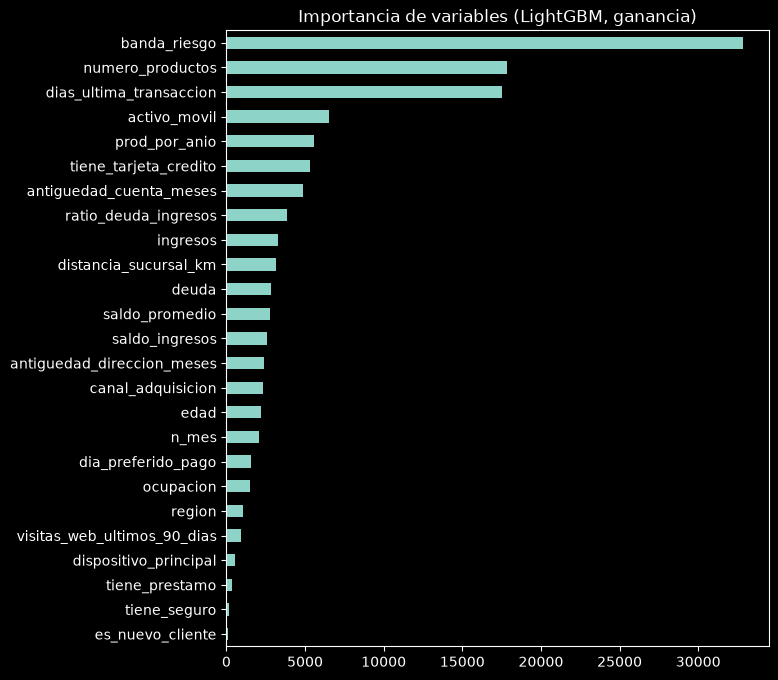

In [18]:
A, _ = preparar_lgb(trn, trn.head(1), F_FE)
m_imp = lgb.LGBMClassifier(**LGB_PARAMS).fit(A, trn.objetivo)
imp = pd.Series(m_imp.booster_.feature_importance('gain'), F_FE).sort_values()
imp.plot(kind='barh', figsize=(7, 8), title='Importancia de variables (LightGBM, ganancia)'); plt.show()

## 9. Entrenamiento final y archivo de entrega
Reentrenamos con **enero a noviembre completos** y predecimos diciembre con la mejor configuración.

In [19]:
a, b = trn, df[df.mes == 202612]
finales = {'logistica_base': lambda: modelo_logistico(a, b, F_BASE),
           'lgb_base':       lambda: modelo_lgb(a, b, F_BASE),
           'lgb_fe':         lambda: modelo_lgb(a, b, F_FE),
           'cat_fe':         lambda: modelo_cat(a, b, F_FE)}
componentes = {'ens_lgb_cat': ['lgb_fe', 'cat_fe'],
               'ens_todos':   ['logistica_base', 'lgb_fe', 'cat_fe']}.get(MEJOR, [MEJOR])
p_test = {n: finales[n]() for n in componentes}
if len(componentes) == 1:
    pred = p_test[componentes[0]]
else:   # ranking promedio reescalado a [0, 1]
    r = sum(rankdata(p_test[n]) for n in componentes)
    pred = (r - r.min()) / (r.max() - r.min())

entrega = pd.DataFrame({'id_cliente': b.id_cliente.values, 'prediccion': pred})
# Verificaciones de formato
assert list(entrega.columns) == ['id_cliente', 'prediccion']
assert len(entrega) == len(test) and (entrega.id_cliente.values == test.id_cliente.values).all()
assert entrega.prediccion.between(0, 1).all() and entrega.prediccion.notna().all()
entrega.to_csv('submission.csv', index=False)
print('submission.csv guardado con', len(entrega), 'filas usando', MEJOR)
entrega.describe()

submission.csv guardado con 9900 filas usando lgb_fe


,id_cliente,prediccion
count,9900.000000,9900.000000
mean,17561.905657,0.142241
std,7424.313150,0.061110
min,2.000000,0.020980
25%,12696.500000,0.119147
50%,19704.000000,0.139444
75%,23824.250000,0.159878
max,26467.000000,0.445910


In [20]:
# En Colab, descarga el archivo
try:
    from google.colab import files; files.download('submission.csv')
except ImportError:
    pass

## 10. Próximos pasos para el equipo
Cada idea se registra en la tabla de experimentos y **solo entra si sube el Gini medio de la validación temporal** (y no aumenta mucho la desviación).

1. **Optimización de hiperparámetros** con Optuna sobre `validar()` (num_leaves, min_child_samples, learning_rate).
2. **Más variables económicas**: interacciones riesgo × productos, buckets de edad o ingresos, recencia de transacción en tramos.
3. **Promedio de semillas** (5 semillas de LightGBM) para estabilizar.
4. **Ponderar meses recientes** (`sample_weight`) por si el comportamiento cambia lentamente.
5. **Modelo de supervivencia** (tiempo discreto) como enfoque alternativo para comparar.
6. **SHAP** para explicar predicciones individuales en la presentación.